In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import hashlib
import glob
import os

In [2]:
catalogue = pd.read_parquet("data/xls/db.parquet.gzip").drop_duplicates()
catalogue = catalogue[catalogue.Score.isin([4,5])]
print(len(catalogue),"reviews in the catalogue for",len(catalogue.Source.unique()),"entries.")
catalogue.head(2)

4375 reviews in the catalogue for 263 entries.


,FromProbono,Origin,Place,Type,Source,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed,reviewBy,reviewDate,pathFile,timestamp,model,id
0,True,D7.21,Prague,Activities,## Panels\nEnergy efficient building envelope ...,The text focuses on the responsible resource u...,Responsible resource use,Living and working environment,Building,4,None,Renovation of building facade panels.,True,NaN,NaN,doc/WIP/Prague/OUT_Reviewed_-Prague_Activities...,2025-04-26 16:56:36,None,None
9,True,D7.21,Prague,Activities,## Exec\nThe PROBONO actions are focused on th...,The text focuses on the design and use of sust...,Responsible resource use,Education and capacity building,Building,4,None,"""Deep building revitalization planning details""",True,NaN,NaN,doc/WIP/Prague/OUT_Reviewed_-Prague_Activities...,2025-04-26 16:56:36,None,None


In [3]:
import src.img as iImg

/home/kelu/projets/probono37k/venv/lib/python3.10/site-packages/langchain_community/utilities/__init__.py:8: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from langchain_community.utilities.requests import (


/home/kelu/projets/probono37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')


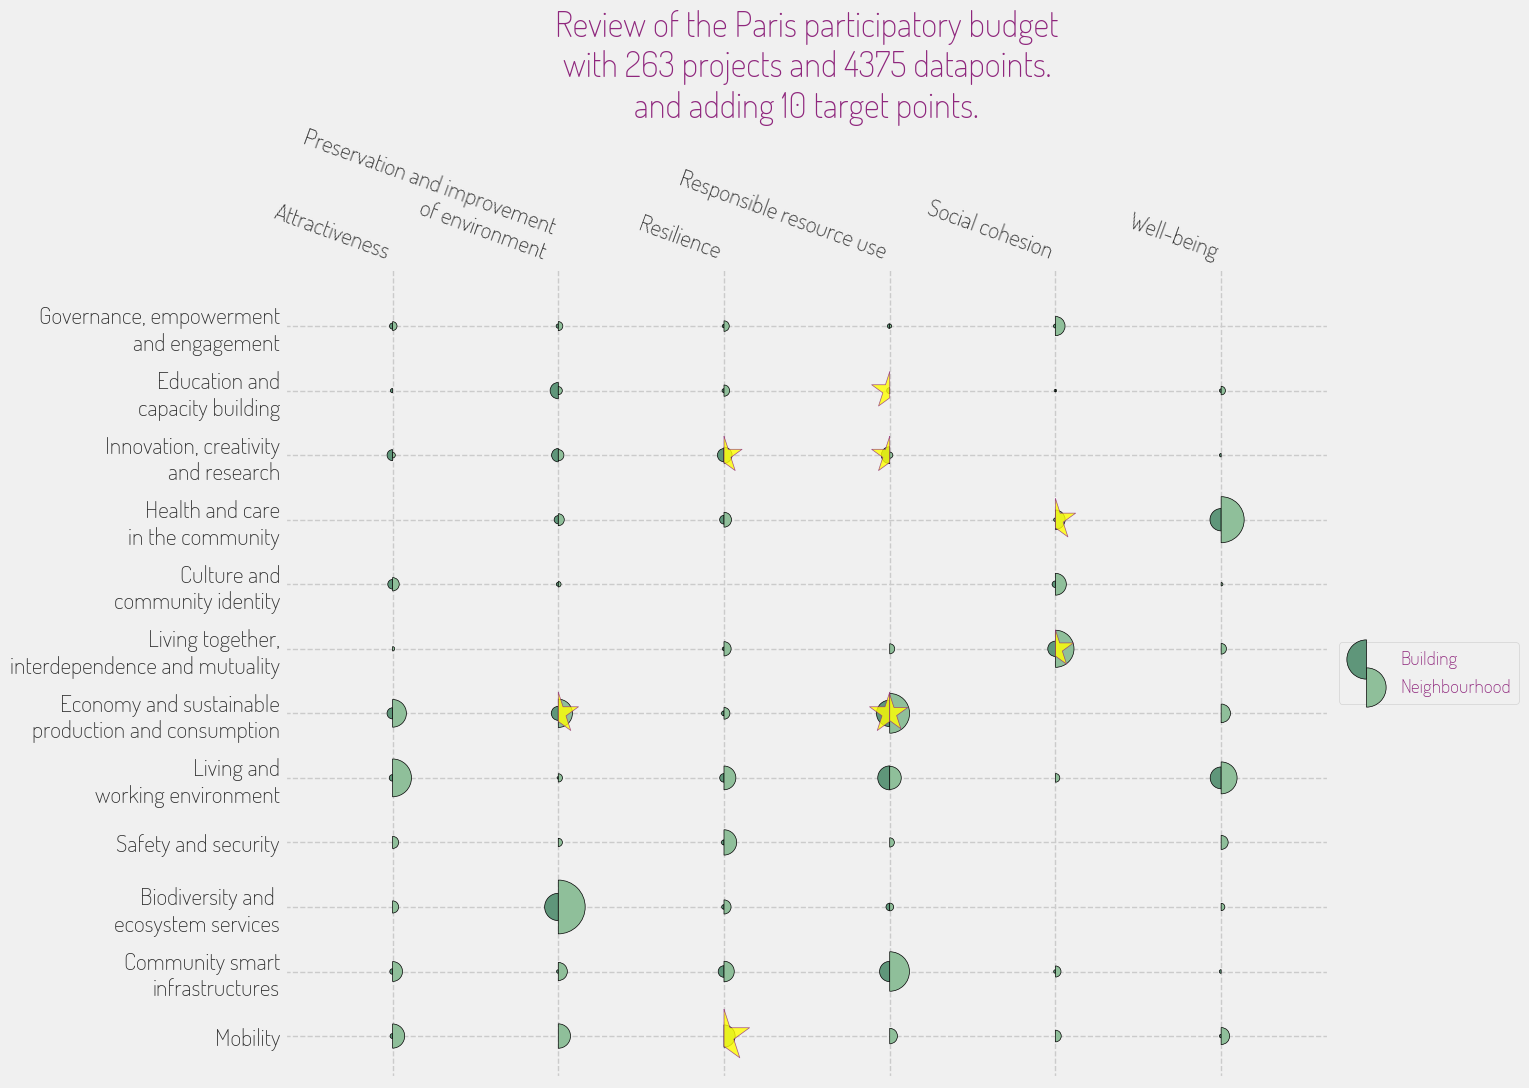

In [4]:
target = catalogue.drop_duplicates(subset=["Purpose","Issue","Scale"]).sample(20)
target.Score = 1
target = catalogue.sample(10)
title = "Review of the Paris participatory budget\nwith "+str(len(catalogue.Source.unique())) +" projects and "+str(len(catalogue))+" datapoints."
title += "\nand adding "+str(len(target))+" target points."
plt, ax = iImg.createImg(catalogue,target,title=title)

In [5]:
def findAction(target,catalogue,n=3):
    results = []
    target["combo"] = target["Purpose"]+"-"+target["Issue"]+"-"+target["Scale"]
    catalogue["combo"] = catalogue["Purpose"]+"-"+catalogue["Issue"]+"-"+catalogue["Scale"]
    while len(results) < n:
        # Let's start
        for ix, row in target.iterrows():
            X, Y, Z, S = row["Purpose"],row["Issue"], row["Scale"], row["Score"]
            sl = catalogue[(catalogue.Purpose == X) & (catalogue.Issue == Y)][["Source","Purpose","Issue","Scale","Score","combo"]]
            sl["mult"] = sl.Scale.apply(lambda x: 5 if x == row["Scale"] else 1)
            sl["fScore"] = sl.Score * sl.mult * S
        choice = pd.pivot_table(sl, values='fScore', index='Source',aggfunc='sum').sort_values(by="fScore", ascending=False).reset_index().iloc[0]
        results.append(choice.Source)
        # Now removing the points ticked
        #print(choice)
        thechoice = list(catalogue[catalogue.Source == choice.Source].combo)
        target = target[~(target.combo.isin(thechoice))]
        #print(thechoice)
        # Now removing the possible from the catalogue
        catalogue = catalogue[~(catalogue.Source == choice.Source)]
        catalogue = catalogue[~(catalogue.combo.isin(thechoice))]

    return results, thechoice

/home/kelu/projets/probono37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize

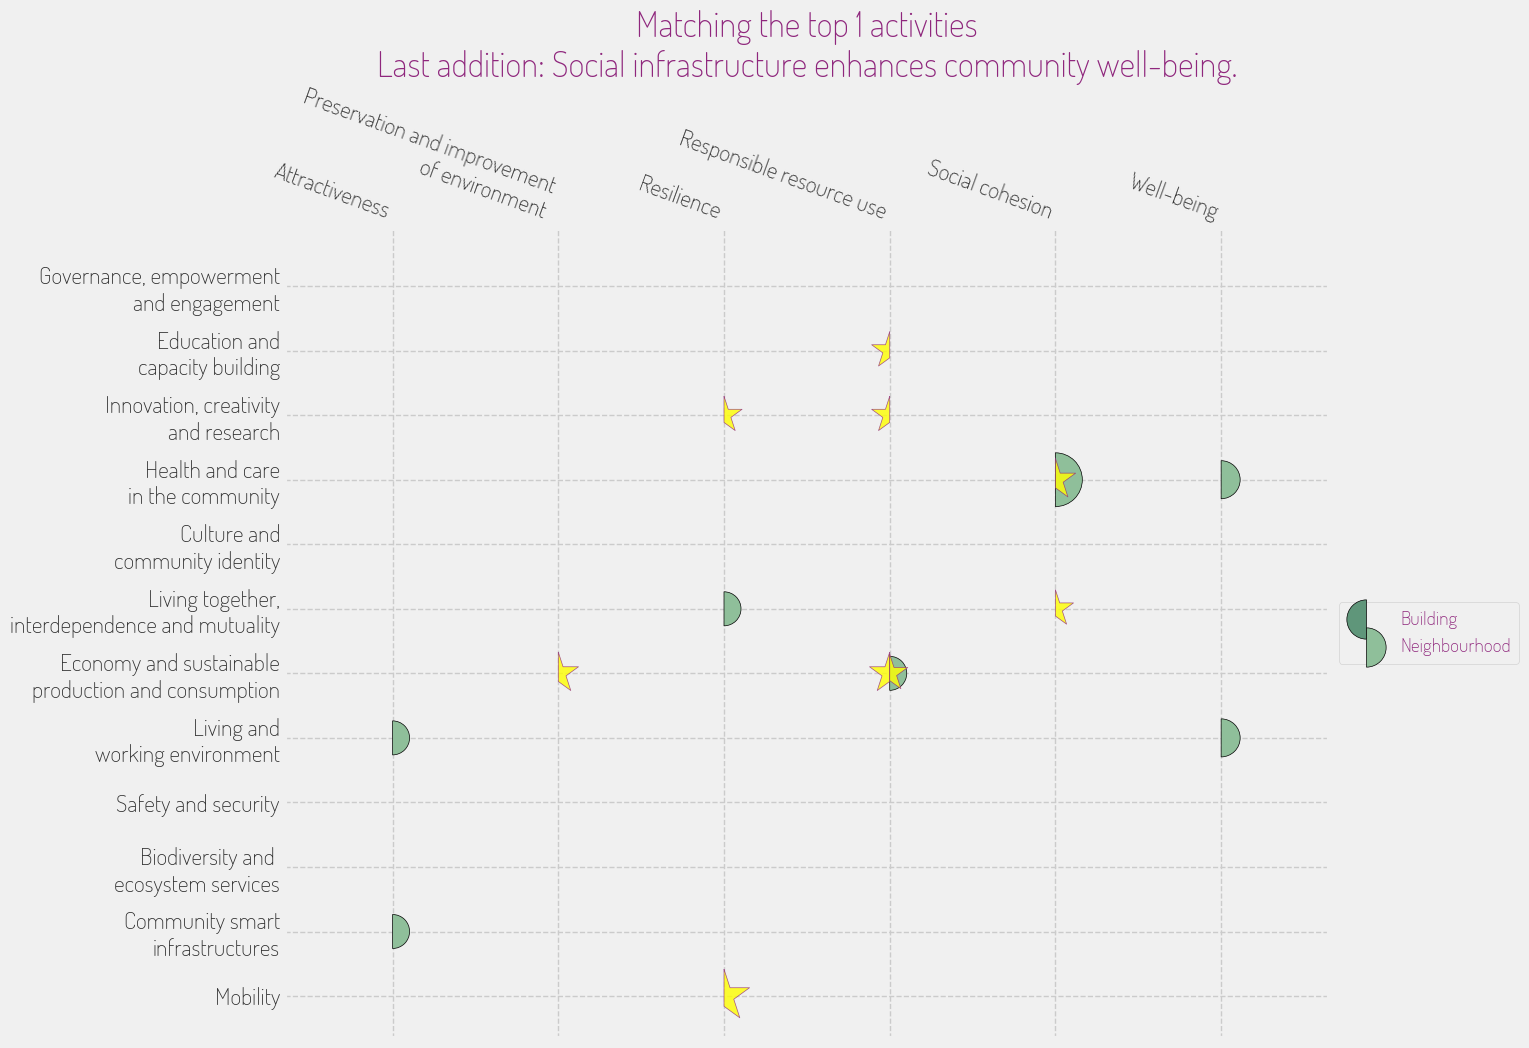

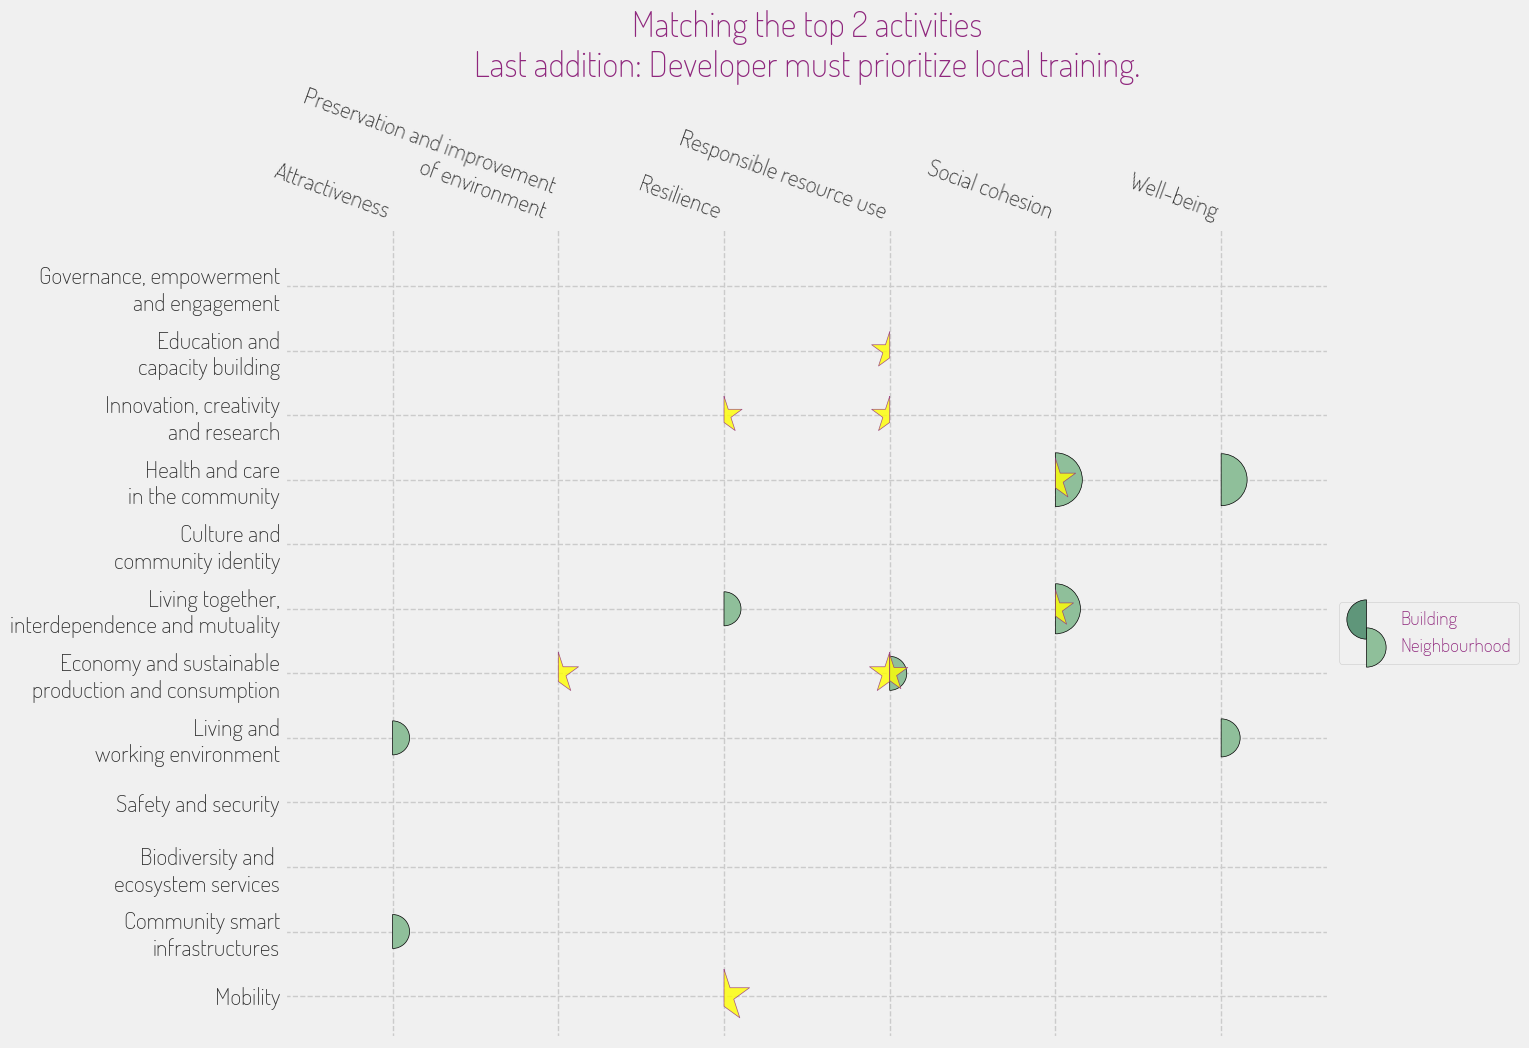

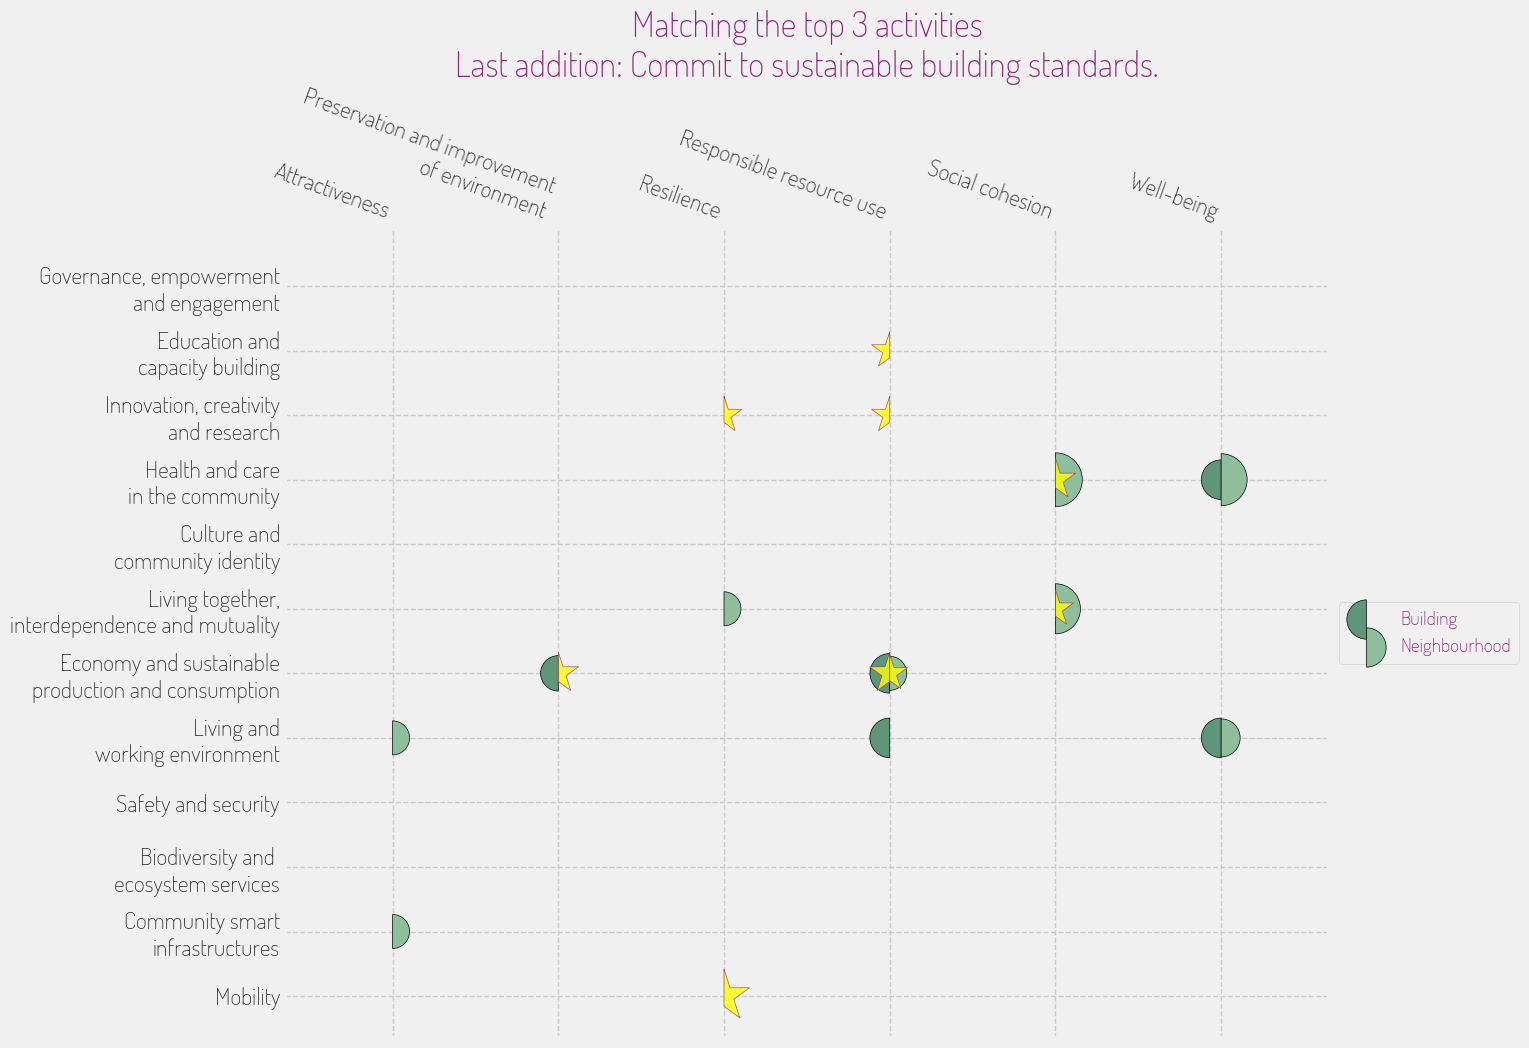

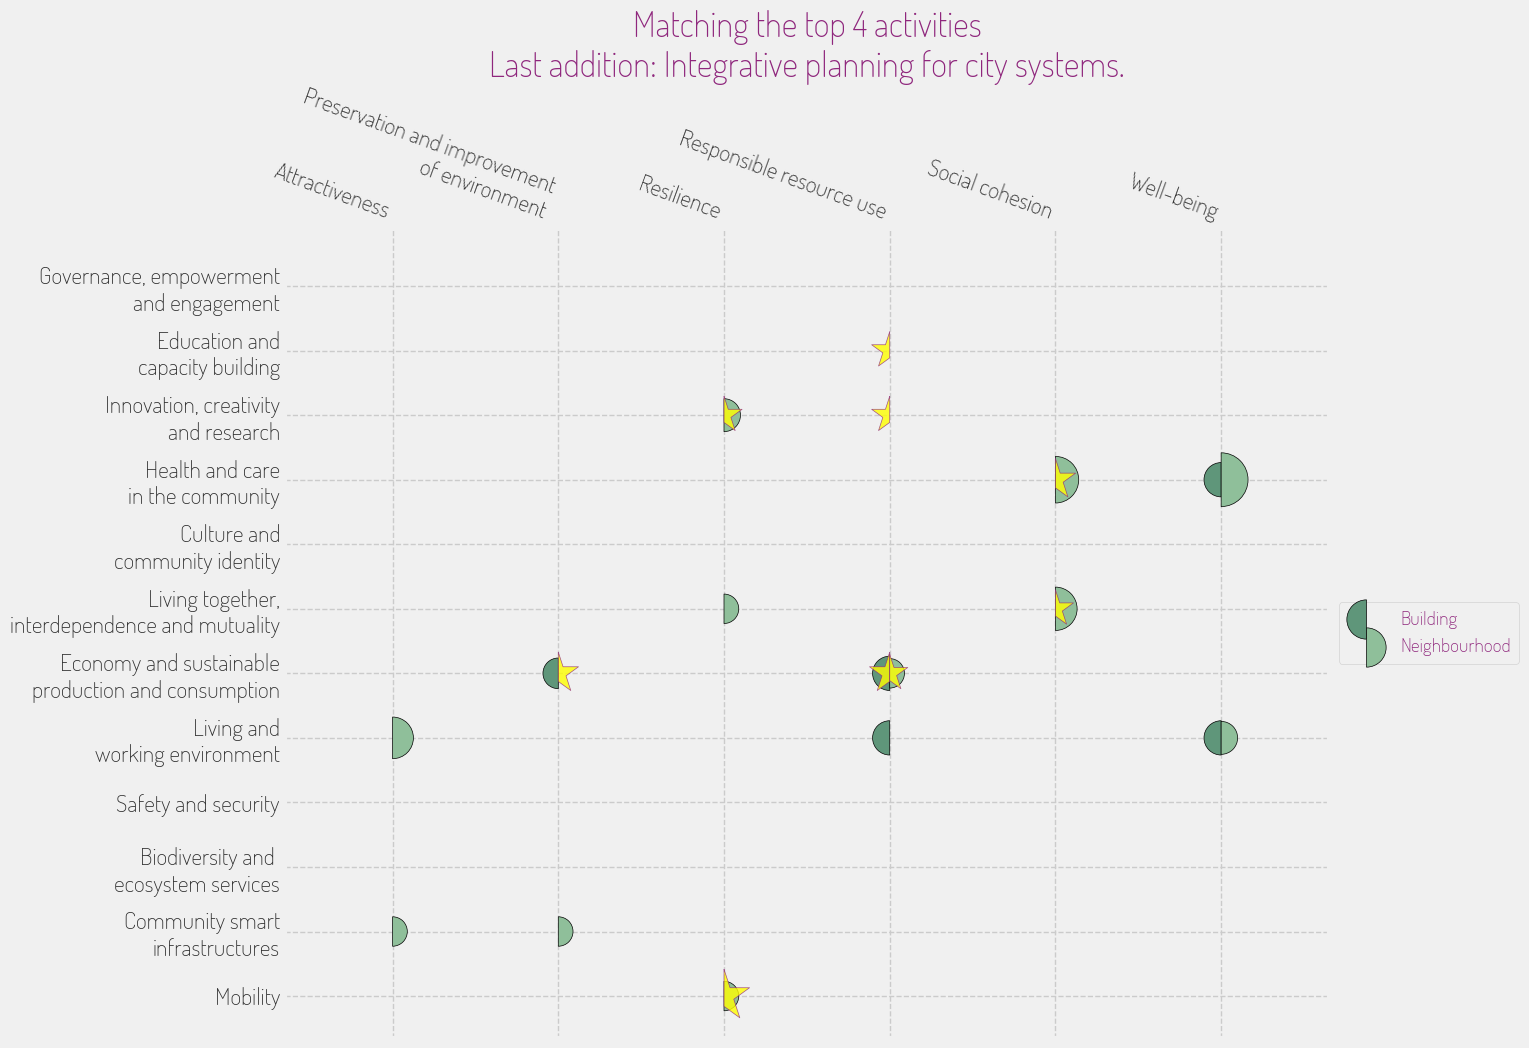

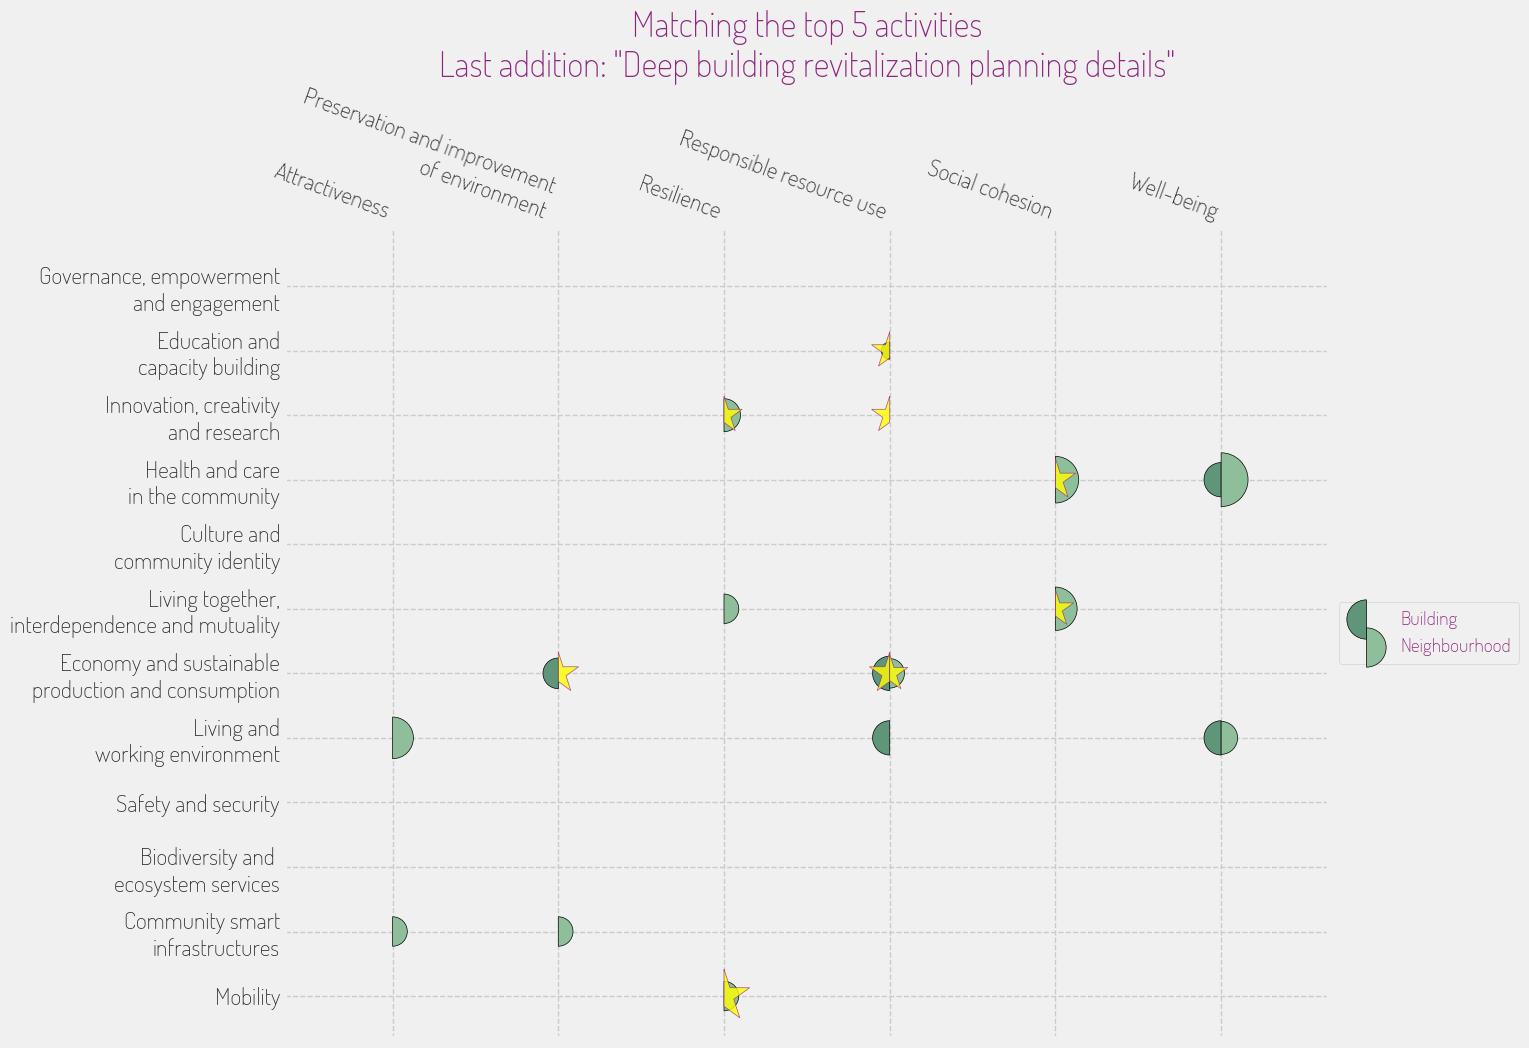

In [7]:
N = 5
for k in range(N):
    res, sl = findAction(target,catalogue, n=k+1)
    title = "Review of the Paris participatory budget\nwith "+str(len(catalogue.Source.unique())) +" projects and "+str(len(catalogue))+" datapoints."
    title += "\nand adding "+str(len(target))+" target points.\n"
    title = "Matching the top "+str(k+1)+" activities\n"
    title += "Last addition: "+catalogue[catalogue.Source == res[-1]].Source_Title.unique()[0]
    plt, ax = iImg.createImg(catalogue[catalogue.Source.isin(res)],target,title=title)
    plt.savefig("outputs/search"+str(k)+".png", bbox_inches='tight')